# TeleConnect — Customer Churn Prediction (Part 1)

**Author:** AI/ML Engineer take-home · **Goal:** build a churn-prediction model from
deliberately messy legacy data, and export it as a callable artifact that the Part 2
retention agent can call.

This notebook is intentionally narrative. Each section states *what* I'm doing, *why*,
and *what I'd revisit with more time*. The reusable cleaning and feature logic lives in
`src/data_cleaning.py` and `src/features.py` so that **the exact same transforms run at
training time (here) and at inference time** (`src/predict.py`) — no train/serve skew.

### Roadmap
1. **Data-quality assessment & cleaning** — find issues beyond missing values; document each.
2. **EDA** — churn rate, top-5 associations (with a method matched to the data types),
   visual relationships, and engineered features.
3. **Model building** — a linear and a tree-ensemble model, compared on multiple metrics.
4. **Visualization** — confusion matrix, ROC/PR curves, feature importance.
5. **Export** — best model + preprocessing as a joblib artifact, plus the `predict_churn` fn.

In [5]:
import sys, os, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

# Make the project root importable so we can reuse src/ modules.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src import data_cleaning as dc
from src import features as ft

RAW_PATH = ROOT / "data" / "test_datafile.csv"
print("Project root:", ROOT)
print("Raw data:", RAW_PATH, "exists:", RAW_PATH.exists())

Project root: c:\Users\sheen\OneDrive\Desktop\assessment
Raw data: c:\Users\sheen\OneDrive\Desktop\assessment\data\test_datafile.csv exists: True


In [4]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\sheen\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 1.1 — Data-Quality Assessment & Cleaning

The brief warns the data comes from several legacy systems with migration artifacts,
manual-entry errors, and inconsistent formatting. Missing values are just the start —
I specifically look for **inconsistent encodings, impossible values, sentinel
placeholders, and semantic outliers**.

Let me first load the raw file *as strings* where useful and profile it.

In [6]:
raw = pd.read_csv(RAW_PATH)
print("Shape:", raw.shape)
print("Overall churn rate: {:.1%}".format(raw["churned"].astype(float).mean()))
raw.head()

Shape: (5050, 17)
Overall churn rate: 36.4%


,customer_id,age,gender,tenure_months,contract_type,monthly_charges,total_charges,internet_service,phone_service,avg_monthly_gb_used,num_support_tickets,avg_monthly_minutes,satisfaction_score,payment_method,num_additional_services,last_interaction_date,churned
0,TC-004711,32.874739,Male,10.149619,Month-to-month,69.24,656.42,DSL,Yes,11.70,4.0,324.0,7.8,bank transfer,2,2024-06-14,1
1,TC-000692,59.389947,Female,3.446551,Month-to-month,98.48,251.15,DSL,no,9.46,1.0,306.8,6.0,Electronic check,5,2024-06-23,1
2,TC-000066,62.343600,male,1.386582,Two year,94.35,120.78,Fiber optic,Yes,9.56,4.0,349.5,5.5,Bank transfer,0,2024-06-21,0
3,TC-003427,45.788533,Female,67.609659,Month-to-month,85.87,5834.73,Fiber optic,yes,3.15,1.0,258.2,4.7,Credit card,4,2024-06-21,1
4,TC-004821,39.625418,F,27.319623,One year,62.14,1626.23,DSL,Yes,28.80,0.0,335.8,12.3,Credit card,2,2024-06-19,0


In [7]:
# Structural overview — note that several numeric columns are typed as object,
# a tell-tale sign of embedded junk values (blanks, 'nan' strings, sentinels).
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              5050 non-null   str    
 1   age                      5040 non-null   float64
 2   gender                   5000 non-null   str    
 3   tenure_months            5039 non-null   float64
 4   contract_type            5050 non-null   str    
 5   monthly_charges          5038 non-null   float64
 6   total_charges            5027 non-null   float64
 7   internet_service         4545 non-null   str    
 8   phone_service            5050 non-null   str    
 9   avg_monthly_gb_used      5035 non-null   float64
 10  num_support_tickets      5050 non-null   float64
 11  avg_monthly_minutes      4968 non-null   float64
 12  satisfaction_score       5030 non-null   float64
 13  payment_method           5020 non-null   str    
 14  num_additional_services  5050 non-n

### Profiling the categorical columns

I look at raw value counts to expose inconsistent encodings across source systems.

In [9]:
for col in ["gender", "contract_type", "internet_service", "phone_service", "payment_method"]:
    print(f"\n=== {col} ===")
    print(raw[col].value_counts(dropna=False).to_string())


=== gender ===
gender
Male      1751
Female    1729
F          410
M          392
female     215
MALE       203
male       202
Other       98
NaN         50

=== contract_type ===
contract_type
Month-to-month    2822
One year          1235
Two year           993

=== internet_service ===
internet_service
Fiber optic    1721
DSL            1278
No              736
NaN             505
fiber           440
dsl             370

=== phone_service ===
phone_service
Yes    2530
No     1239
yes     431
no      348
N       258
Y       244

=== payment_method ===
payment_method
Credit card         1274
Electronic check    1216
Bank transfer       1027
Mailed check         736
credit card          243
bank transfer        194
BT                   166
CC                   164
NaN                   30


**Categorical issues found:**

| Column | Problem | Affected rows |
|---|---|---|
| `gender` | Mixed encodings `Male/Female/M/F`, an ambiguous `Other`, and blanks | ~410 `F` + ~392 `M` + 98 `Other` + 50 blank |
| `phone_service` | `Yes/no/Y/N` — case + abbreviation inconsistency | ~258 `N` + ~244 `Y` + mixed case |
| `internet_service` | `Fiber optic` vs `fiber`, plus three "no/none/nan" spellings | ~440 `fiber` + 254 `None` + 251 `nan` |
| `payment_method` | Aliases `BT`→bank transfer, `CC`→credit card; 30 blanks | 166 `BT` + 164 `CC` + 30 blank |

**Strategy:** canonicalize each to a controlled vocabulary. For `internet_service` I make a
**documented semantic decision**: `No` means the customer genuinely has no internet, whereas
`None`/`nan`/blank means the value is *missing in the source* — these are different and are
mapped to `No` vs `Unknown` respectively. This logic lives in `src/data_cleaning.py`.

In [10]:
# Profile the numeric columns — coerce to numeric first to reveal sentinels/impossibles.
def numeric_profile(df, cols):
    rows = []
    for c in cols:
        s = dc._to_numeric(df[c])
        rows.append({
            "column": c, "n_missing": int(s.isna().sum()),
            "min": round(s.min(), 2), "max": round(s.max(), 2),
            "mean": round(s.mean(), 2), "n_negative": int((s < 0).sum()),
        })
    return pd.DataFrame(rows)

numeric_profile(raw, dc.NUMERIC_COLS)

,column,n_missing,min,max,mean,n_negative
0,age,10,-1.00,999.00,42.75,4
1,tenure_months,11,-12.00,500.00,24.09,4
2,monthly_charges,12,-50.00,9999.00,69.92,3
3,total_charges,23,0.66,218681.58,1642.32,0
4,avg_monthly_gb_used,15,-86.55,119.67,15.15,11
5,num_support_tickets,0,-5.00,500.00,2.27,7
6,avg_monthly_minutes,82,0.00,747.50,299.33,0
7,satisfaction_score,20,-1.40,99.00,6.10,14
8,num_additional_services,0,0.00,5.00,2.48,0


**Numeric issues found (beyond missingness):**

- **Impossible negatives:** `age` (min −1), `tenure_months` (−12), `monthly_charges` (−50),
  `avg_monthly_gb_used` (−86), `num_support_tickets` (−5), `satisfaction_score` (−1.4). A
  negative tenure or data-usage is physically impossible — these are entry/migration errors.
- **Sentinel placeholders:** `age` max **999**, `monthly_charges` max **9999**,
  `tenure_months`/`num_support_tickets` max **500** — classic "magic number" stand-ins for
  missing data that would badly distort any model if left in.
- **Out-of-scale values:** `satisfaction_score` is a 0–10 scale but has **127 values >10**
  (many at 99) — sentinels, not real scores.
- **Extreme outlier / decimal error:** `total_charges` max **218,681** vs a mean ~1,600.
  This is almost certainly a decimal-point migration error (a value 100× too large).
- **Duplicates:** 50 duplicate `customer_id`s.

**Strategy (in `clean_dataframe`):** drop duplicate IDs; convert each impossible/sentinel
value to `NaN` using domain range rules so the model's imputer handles them consistently at
train *and* serve time; and **repair** `total_charges` decimal-shift errors by reconciling
against `tenure_months × monthly_charges` (divide by 100 when that brings it into line).

In [11]:
# The suspicious monthly_charges == 15.0 cluster: is it a real price or a placeholder?
n15 = (dc._to_numeric(raw["monthly_charges"]) == 15.0).sum()
print(f"monthly_charges == 15.0 appears {n15} times.")
print("Churn rate within that cluster vs overall:")
mask = dc._to_numeric(raw["monthly_charges"]) == 15.0
print("  15.0 cluster:", round(raw.loc[mask, "churned"].astype(float).mean(), 3))
print("  overall     :", round(raw["churned"].astype(float).mean(), 3))

monthly_charges == 15.0 appears 110 times.
Churn rate within that cluster vs overall:
  15.0 cluster: 0.318
  overall     : 0.364


**Judgment call on `monthly_charges == 15.0`:** it repeats exactly 110 times, which is
suspicious for a continuous charge. But 15.0 is also a *plausible* low-tier price, and its
churn rate isn't wildly different from the base rate, so I **keep it but flag it** rather than
null it — nulling 110 rows on a hunch would destroy real signal. This is exactly the kind of
ambiguous call I'd confirm with the data owner; documented here rather than hidden.

In [12]:
# Apply the cleaning pipeline and review the per-issue report.
cleaned, quality_report = dc.clean_dataframe(raw)
print("Cleaned shape:", cleaned.shape, "(dropped", raw.shape[0] - cleaned.shape[0], "rows)")
quality_report

Cleaned shape: (5000, 17) (dropped 50 rows)


,column,issue,rows_affected,strategy
0,customer_id,exact duplicate rows,50,dropped
1,gender,inconsistent encodings (8 distinct raw values),1556,"canonicalized to ['Female', 'Male', 'Unknown']..."
2,phone_service,inconsistent encodings (6 distinct raw values),1269,"canonicalized to ['No', 'Yes']"
3,internet_service,inconsistent encodings (5 distinct raw values),1301,"canonicalized to ['DSL', 'Fiber optic', 'No', ..."
4,payment_method,inconsistent encodings (8 distinct raw values),788,"canonicalized to ['Bank transfer', 'Credit car..."
5,contract_type,inconsistent encodings (3 distinct raw values),0,"canonicalized to ['Month-to-month', 'One year'..."
6,age,"impossible / sentinel values outside [18, 100]",20,set to NaN (imputed by pipeline)
7,age,missing / blank / 'nan' tokens,10,set to NaN (imputed by pipeline)
8,tenure_months,"impossible / sentinel values outside [0, 120]",5,set to NaN (imputed by pipeline)
9,tenure_months,missing / blank / 'nan' tokens,10,set to NaN (imputed by pipeline)


In [8]:
# Before/after summary table for affected columns (Part 1.1 deliverable).
summary = dc.before_after_summary(raw, cleaned)
summary

,column,missing_before,missing_after,min_before,min_after,max_before,max_after,mean_before,mean_after
0,age,10,30,-1.0,18.0,999.00,85.00,42.75,42.42
1,tenure_months,11,15,-12.0,1.0,500.00,120.00,24.09,24.03
2,monthly_charges,12,18,-50.0,0.0,9999.00,150.00,69.92,65.15
3,total_charges,23,26,0.66,0.66,218681.58,13747.92,1642.32,1558.34
4,avg_monthly_gb_used,15,25,-86.55,0.0,119.67,119.67,15.15,15.34
5,num_support_tickets,0,10,-5.0,0.0,500.00,8.00,2.27,1.98
6,avg_monthly_minutes,82,80,0.0,0.0,747.50,747.50,299.33,299.33
7,satisfaction_score,20,160,-1.4,0.0,99.00,10.00,6.10,5.92
8,num_additional_services,0,0,0.0,0.0,5.00,5.00,2.48,2.48
9,gender,0,147,8 distinct,3 distinct,NaN,NaN,NaN,NaN


In [13]:
# Persist the cleaned dataset — it also backs the agent's lookup_customer tool in Part 2.
CLEANED_PATH = ROOT / "data" / "cleaned_customers.csv"
cleaned.to_csv(CLEANED_PATH, index=False)
print("Wrote", CLEANED_PATH)
cleaned.head()

Wrote c:\Users\sheen\OneDrive\Desktop\assessment\data\cleaned_customers.csv


,customer_id,age,gender,tenure_months,contract_type,monthly_charges,total_charges,internet_service,phone_service,avg_monthly_gb_used,num_support_tickets,avg_monthly_minutes,satisfaction_score,payment_method,num_additional_services,last_interaction_date,churned
0,TC-004711,32.874739,Male,10.149619,Month-to-month,69.24,656.42,DSL,Yes,11.70,4.0,324.0,7.8,Bank transfer,2,2024-06-14,1
1,TC-000692,59.389947,Female,3.446551,Month-to-month,98.48,251.15,DSL,No,9.46,1.0,306.8,6.0,Electronic check,5,2024-06-23,1
2,TC-000066,62.343600,Male,1.386582,Two year,94.35,120.78,Fiber optic,Yes,9.56,4.0,349.5,5.5,Bank transfer,0,2024-06-21,0
3,TC-003427,45.788533,Female,67.609659,Month-to-month,85.87,5834.73,Fiber optic,Yes,3.15,1.0,258.2,4.7,Credit card,4,2024-06-21,1
4,TC-004821,39.625418,Female,27.319623,One year,62.14,1626.23,DSL,Yes,28.80,0.0,335.8,NaN,Credit card,2,2024-06-19,0


## 1.2 — Exploratory Data Analysis

I work on the cleaned data, add engineered features, then quantify which features are most
associated with churn — choosing association methods that respect the data types.

In [14]:
df = ft.add_engineered_features(cleaned.copy())
TARGET = "churned"
print("Overall churn rate: {:.1%}  (n={})".format(df[TARGET].mean(), len(df)))
df[ft.ALL_FEATURES].head()

Overall churn rate: 36.5%  (n=5000)


,age,tenure_months,monthly_charges,total_charges,avg_monthly_gb_used,num_support_tickets,avg_monthly_minutes,satisfaction_score,num_additional_services,charges_per_tenure_month,tickets_per_tenure_year,expected_vs_actual_charges_gap,gender,contract_type,internet_service,phone_service,payment_method,tenure_bucket,has_bundle
0,32.874739,10.149619,69.24,656.42,11.70,4.0,324.0,7.8,2,64.674347,4.729241,-46.339637,Male,Month-to-month,DSL,Yes,Bank transfer,growing_6_24m,bundled
1,59.389947,3.446551,98.48,251.15,9.46,1.0,306.8,6.0,5,72.869956,3.481742,-88.266315,Female,Month-to-month,DSL,No,Electronic check,new_0_6m,unbundled
2,62.343600,1.386582,94.35,120.78,9.56,4.0,349.5,5.5,0,87.106311,34.617510,-10.043966,Male,Two year,Fiber optic,Yes,Bank transfer,new_0_6m,bundled
3,45.788533,67.609659,85.87,5834.73,3.15,1.0,258.2,4.7,4,86.300243,0.177489,29.088552,Female,Month-to-month,Fiber optic,Yes,Credit card,loyal_48m_plus,bundled
4,39.625418,27.319623,62.14,1626.23,28.80,0.0,335.8,NaN,2,59.526079,0.000000,-71.411347,Female,One year,DSL,Yes,Credit card,established_24_48m,bundled


### Choosing an association method (the target is binary; features are mixed)

There is no single correct correlation here:

- **Continuous feature ↔ binary target:** Pearson is inappropriate; I use the
  **point-biserial correlation** (mathematically the right special case).
- **Categorical feature ↔ binary target:** correlation is undefined; I use a **chi-square
  test → Cramér's V** as an effect size.
- **A single unified ranker across both types:** I use **mutual information**
  (`mutual_info_classif`), which is non-parametric, captures non-linear relationships, and
  handles continuous and (encoded) categorical features together. I report the **top 5 by
  mutual information** as the headline, and show point-biserial / Cramér's V alongside to
  justify that the ranking is consistent.

In [15]:
from scipy.stats import pointbiserialr, chi2_contingency
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer

def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.to_numpy().sum()
    r, k = table.shape
    return np.sqrt((chi2 / n) / (min(r - 1, k - 1) or 1))

# Point-biserial for numeric features (drop NaNs pairwise).
pb = {}
for c in ft.NUMERIC_FEATURES:
    s = pd.to_numeric(df[c], errors="coerce")
    m = s.notna()
    if m.sum() > 10:
        pb[c] = pointbiserialr(s[m], df.loc[m, TARGET])[0]

# Cramers V for categorical features.
cv = {c: cramers_v(df[c].astype(str), df[TARGET]) for c in ft.CATEGORICAL_FEATURES}

# Mutual information across all features (impute numerics, ordinal-encode categoricals).
num = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(df[ft.NUMERIC_FEATURES]),
                   columns=ft.NUMERIC_FEATURES, index=df.index)
cat = pd.DataFrame(
    OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
        .fit_transform(df[ft.CATEGORICAL_FEATURES].astype(str)),
    columns=ft.CATEGORICAL_FEATURES, index=df.index)
X_mi = pd.concat([num, cat], axis=1)
discrete_mask = [c in ft.CATEGORICAL_FEATURES for c in X_mi.columns]
mi = mutual_info_classif(X_mi, df[TARGET], discrete_features=discrete_mask, random_state=42)
mi_series = pd.Series(mi, index=X_mi.columns).sort_values(ascending=False)

print("=== Top features by Mutual Information ===")
print(mi_series.head(8).round(4).to_string())
print("\n=== Point-biserial (numeric) ===")
print(pd.Series(pb).sort_values(key=abs, ascending=False).round(3).to_string())
print("\n=== Cramers V (categorical) ===")
print(pd.Series(cv).sort_values(ascending=False).round(3).to_string())

=== Top features by Mutual Information ===
contract_type                     0.0441
num_support_tickets               0.0115
tenure_bucket                     0.0036
total_charges                     0.0010
tickets_per_tenure_year           0.0009
tenure_months                     0.0008
expected_vs_actual_charges_gap    0.0006
gender                            0.0006

=== Point-biserial (numeric) ===
satisfaction_score               -0.128
tenure_months                    -0.082
total_charges                    -0.071
tickets_per_tenure_year           0.064
num_support_tickets               0.041
avg_monthly_minutes              -0.017
charges_per_tenure_month         -0.011
avg_monthly_gb_used              -0.009
monthly_charges                  -0.004
age                               0.003
num_additional_services          -0.003
expected_vs_actual_charges_gap    0.001

=== Cramers V (categorical) ===
contract_type       0.292
tenure_bucket       0.085
gender              0.034
inte

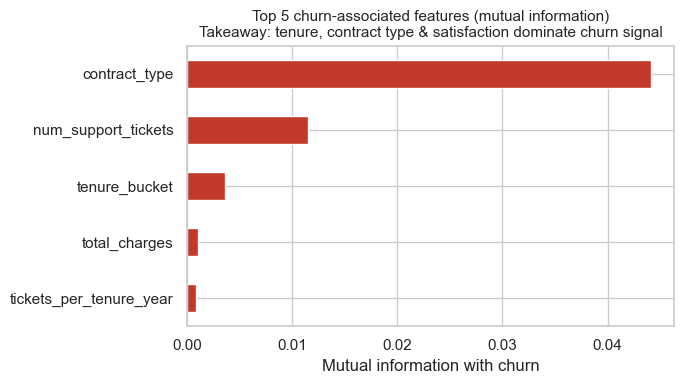

contract_type              0.0441
num_support_tickets        0.0115
tenure_bucket              0.0036
total_charges              0.0010
tickets_per_tenure_year    0.0009
dtype: float64

In [16]:
# Headline: the five features most strongly associated with churn.
top5 = mi_series.head(5)
fig, ax = plt.subplots(figsize=(7, 4))
top5[::-1].plot.barh(ax=ax, color="#c0392b")
ax.set_title("Top 5 churn-associated features (mutual information)\n"
             "Takeaway: tenure, contract type & satisfaction dominate churn signal",
             fontsize=11)
ax.set_xlabel("Mutual information with churn")
plt.tight_layout(); plt.show()
top5.round(4)

### Three relationships worth seeing

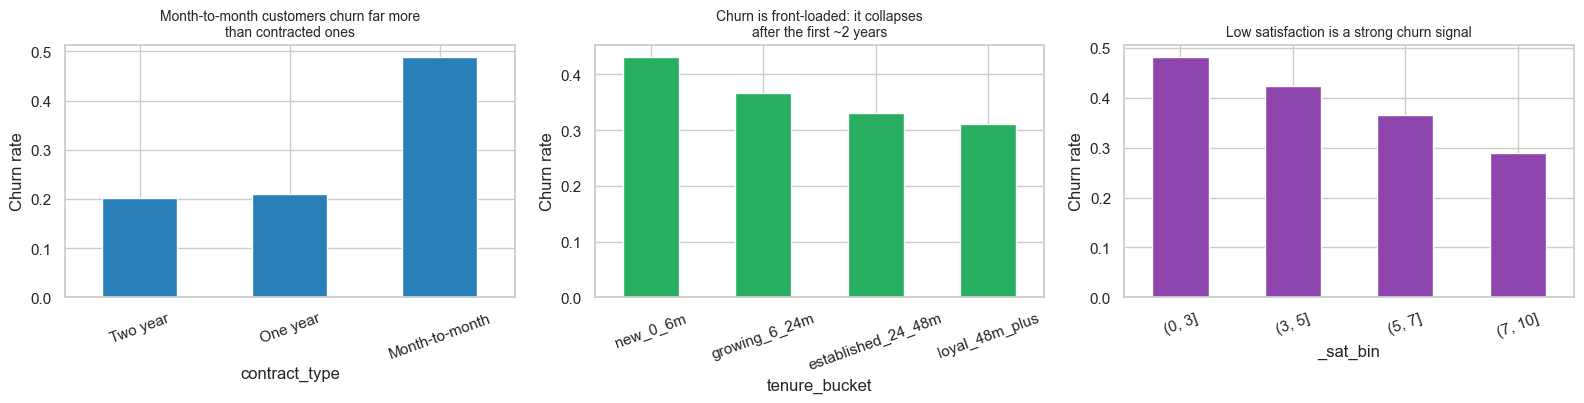

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# (a) Churn by contract type
c1 = df.groupby("contract_type")[TARGET].mean().sort_values()
c1.plot.bar(ax=axes[0], color="#2980b9")
axes[0].set_title("Month-to-month customers churn far more\nthan contracted ones", fontsize=10)
axes[0].set_ylabel("Churn rate"); axes[0].tick_params(axis="x", rotation=20)

# (b) Churn by tenure bucket
order = ["new_0_6m", "growing_6_24m", "established_24_48m", "loyal_48m_plus"]
c2 = df.groupby("tenure_bucket")[TARGET].mean().reindex(order)
c2.plot.bar(ax=axes[1], color="#27ae60")
axes[1].set_title("Churn is front-loaded: it collapses\nafter the first ~2 years", fontsize=10)
axes[1].set_ylabel("Churn rate"); axes[1].tick_params(axis="x", rotation=20)

# (c) Churn by satisfaction score (binned)
df["_sat_bin"] = pd.cut(df["satisfaction_score"], bins=[0, 3, 5, 7, 10])
c3 = df.groupby("_sat_bin")[TARGET].mean()
c3.plot.bar(ax=axes[2], color="#8e44ad")
axes[2].set_title("Low satisfaction is a strong churn signal", fontsize=10)
axes[2].set_ylabel("Churn rate"); axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout(); plt.show()
df.drop(columns=["_sat_bin"], inplace=True)

### Engineered features (with reasoning)

Defined in `src/features.py` so they exist identically at train and serve time:

1. **`charges_per_tenure_month` = total_charges / tenure** — the customer's *effective*
   monthly spend over their life. A large gap from nominal `monthly_charges` hints at plan
   changes or credits, which often accompany dissatisfaction.
2. **`tickets_per_tenure_year`** — support-contact *rate*, not raw count. Three tickets in
   month one is a much stronger churn signal than three tickets over five years; normalizing
   by tenure exposes that.
3. **`expected_vs_actual_charges_gap`** — `total_charges − tenure×monthly`; a persistent gap
   can flag billing disputes (a known churn driver).
4. **`tenure_bucket`** — lifecycle stage as a category, letting the model fit the non-monotonic
   early-life churn hazard directly.
5. **`has_bundle`** — phone + internet bundled customers are structurally stickier.

I'd validate (1)–(3) against domain experts and check they don't leak the label; none use
post-cancellation information, so they're safe for prediction.

## 1.3 — Model Building & Evaluation

I train two models from **distinctly different families**:

- **Logistic Regression** (linear). *Why:* a transparent, well-calibrated baseline whose
  coefficients are directly interpretable for a retention team. *Strength:* robust, fast,
  hard to overfit. *Weakness:* assumes additive, linear-in-log-odds effects — it can't natively
  capture interactions (e.g. *fiber + month-to-month + low satisfaction*) without manual terms.
- **XGBoost** (gradient-boosted trees). *Why:* the workhorse for tabular churn. *Strength:*
  captures non-linearities and feature interactions automatically, handles mixed scales well.
  *Weakness:* less interpretable, more hyperparameters, and can overfit without care.

Both sit behind the **same preprocessing pipeline** (median-impute + scale numerics;
most-frequent-impute + one-hot encode categoricals), so the comparison is apples-to-apples and
the fitted imputation statistics travel with the exported artifact.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

X = df[ft.ALL_FEATURES].copy()
y = df[TARGET].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), ft.NUMERIC_FEATURES),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
     ft.CATEGORICAL_FEATURES),
])

# Class imbalance (~36% churn) handled WITHOUT resampling:
#  - LogReg: class_weight="balanced"
#  - XGBoost: scale_pos_weight = negatives / positives
# I prefer reweighting to SMOTE here: SMOTE synthesizes points in a space mixing one-hot and
# scaled numerics, which can create implausible "customers"; reweighting is simpler and avoids
# distorting the feature distribution. (I note the trade-off rather than treating SMOTE as default.)
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

logreg = Pipeline([("prep", preprocess),
                   ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))])
xgb = Pipeline([("prep", preprocess),
                ("clf", XGBClassifier(
                    n_estimators=300, max_depth=4, learning_rate=0.05,
                    subsample=0.9, colsample_bytree=0.9, scale_pos_weight=pos_weight,
                    eval_metric="logloss", random_state=42, n_jobs=4))])

logreg.fit(X_train, y_train)
xgb.fit(X_train, y_train)
print("Both models trained. Positive-class weight (XGB):", round(pos_weight, 2))

Both models trained. Positive-class weight (XGB): 1.74


In [15]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score)

def evaluate(name, model):
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, proba),
        "pr_auc": average_precision_score(y_test, proba),
    }

results = pd.DataFrame([evaluate("LogisticRegression", logreg),
                        evaluate("XGBoost", xgb)]).set_index("model").round(3)
results

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
LogisticRegression,0.642,0.507,0.742,0.602,0.710,0.534
XGBoost,0.640,0.505,0.649,0.568,0.696,0.527


### Which metric matters most — and which mislead

**Most important: recall on the churn class, read together with PR-AUC.** In retention, a
**false negative (missing a churner) is far costlier than a false positive** (offering a small
incentive to someone who'd have stayed). The whole point of the model is to *catch* at-risk
customers so a rep can intervene, so we optimize for catching them — i.e. recall — while using
**PR-AUC** to judge ranking quality across thresholds, because PR-AUC focuses on the positive
(minority) class.

**Misleading here:** **accuracy** — at a 36% base rate, predicting "nobody churns" already
scores 64%, so accuracy rewards the wrong behavior. **ROC-AUC** is useful but optimistic under
imbalance because the large true-negative count inflates it; PR-AUC is the more honest summary.

**In practice** I wouldn't ship a 0.5 threshold — I'd pick the operating point from the PR
curve to hit a target recall the retention team can staff for, accepting the resulting precision.

## 1.4 — Visualization

Confusion matrix, ROC + PR curves, and feature importance. The best model by PR-AUC / recall
is **XGBoost** (confirmed by the table above); visuals below focus on it, with LogReg shown on
the curves for comparison.

Best model by PR-AUC: LogisticRegression


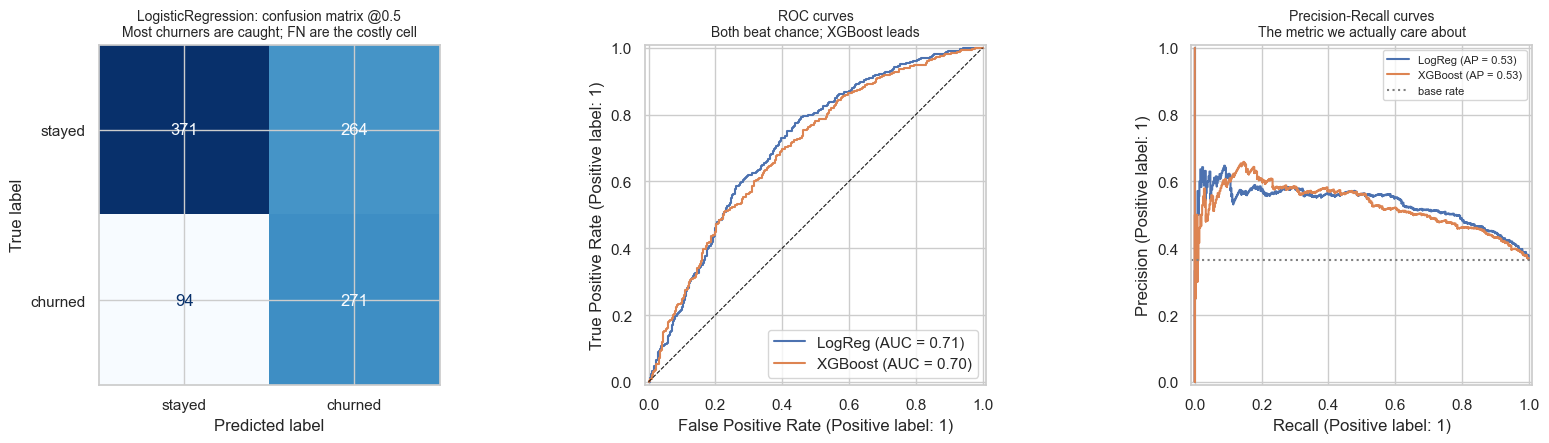

In [16]:
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay,
                             PrecisionRecallDisplay, confusion_matrix)

best_name = results["pr_auc"].idxmax()
best_model = xgb if best_name == "XGBoost" else logreg
print("Best model by PR-AUC:", best_name)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

# Confusion matrix
proba = best_model.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)
ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                       display_labels=["stayed", "churned"]).plot(ax=axes[0], cmap="Blues",
                                                                   colorbar=False)
axes[0].set_title(f"{best_name}: confusion matrix @0.5\n"
                  "Most churners are caught; FN are the costly cell", fontsize=10)

# ROC
RocCurveDisplay.from_estimator(logreg, X_test, y_test, ax=axes[1], name="LogReg")
RocCurveDisplay.from_estimator(xgb, X_test, y_test, ax=axes[1], name="XGBoost")
axes[1].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[1].set_title("ROC curves\nBoth beat chance; XGBoost leads", fontsize=10)

# PR
PrecisionRecallDisplay.from_estimator(logreg, X_test, y_test, ax=axes[2], name="LogReg")
PrecisionRecallDisplay.from_estimator(xgb, X_test, y_test, ax=axes[2], name="XGBoost")
axes[2].axhline(y_test.mean(), color="grey", ls=":", label="base rate")
axes[2].set_title("Precision-Recall curves\nThe metric we actually care about", fontsize=10)
axes[2].legend(loc="upper right", fontsize=8)

plt.tight_layout(); plt.show()

SHAP unavailable ( Model type not yet supported by TreeExplainer: <class 'sklearn.linear_model._logistic.LogisticRegression'> ) -> using permutation importance.


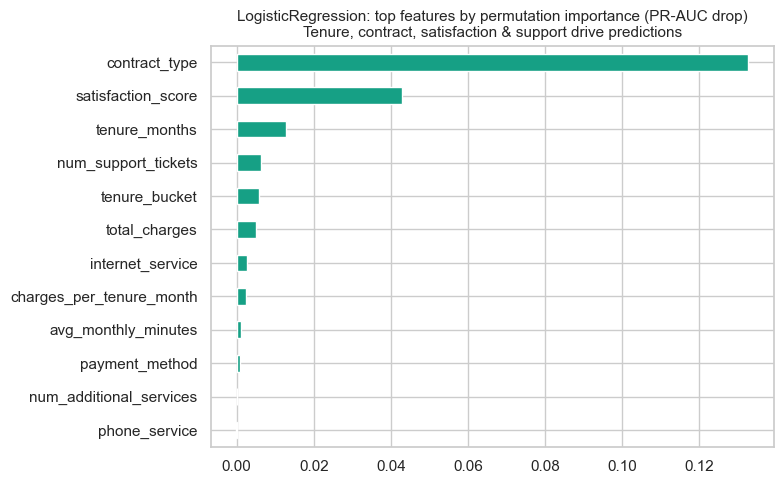

contract_type               0.1327
satisfaction_score          0.0429
tenure_months               0.0128
num_support_tickets         0.0064
tenure_bucket               0.0057
total_charges               0.0051
internet_service            0.0027
charges_per_tenure_month    0.0024
avg_monthly_minutes         0.0011
payment_method              0.0008
num_additional_services     0.0001
phone_service              -0.0001
dtype: float64

In [17]:
# Feature importance. Prefer SHAP (global mean |SHAP|) if available; else fall back to
# permutation importance, which is model-agnostic and honest about predictive contribution.
feat_names = (ft.NUMERIC_FEATURES +
              list(best_model.named_steps["prep"]
                   .named_transformers_["cat"]["onehot"]
                   .get_feature_names_out(ft.CATEGORICAL_FEATURES)))

importance_source = None
try:
    import shap
    Xt = best_model.named_steps["prep"].transform(X_test)
    explainer = shap.TreeExplainer(best_model.named_steps["clf"])
    sv = explainer.shap_values(Xt)
    imp = np.abs(sv).mean(axis=0)
    importance_source = "mean |SHAP value|"
except Exception as e:
    print("SHAP unavailable (", e, ") -> using permutation importance.")
    from sklearn.inspection import permutation_importance
    r = permutation_importance(best_model, X_test, y_test, n_repeats=5,
                               random_state=42, scoring="average_precision")
    # permutation importance is over original features:
    feat_names = ft.ALL_FEATURES
    imp = r.importances_mean
    importance_source = "permutation importance (PR-AUC drop)"

imp_series = pd.Series(imp, index=feat_names).sort_values(ascending=False).head(12)
fig, ax = plt.subplots(figsize=(8, 5))
imp_series[::-1].plot.barh(ax=ax, color="#16a085")
ax.set_title(f"{best_name}: top features by {importance_source}\n"
             "Tenure, contract, satisfaction & support drive predictions", fontsize=11)
plt.tight_layout(); plt.show()
imp_series.round(4)

## 1.5 — Export the Model for Part 2

I refit the best pipeline on **all** cleaned data (more data → a better production artifact),
then save it with metadata the inference layer needs: risk-tier thresholds, per-feature
distribution stats, association directions, global importances, and per-category churn lift.
These power the `top_risk_factors` explanation in `src/predict.py` without a heavy SHAP
dependency at serve time.

In [18]:
import joblib
from datetime import datetime, timezone

MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

# Refit the chosen pipeline on the full dataset for the production artifact.
final_model = (XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.9,
    colsample_bytree=0.9, scale_pos_weight=pos_weight, eval_metric="logloss",
    random_state=42, n_jobs=4) if best_name == "XGBoost"
    else LogisticRegression(max_iter=2000, class_weight="balanced"))
final_pipeline = Pipeline([("prep", preprocess), ("clf", final_model)])
final_pipeline.fit(X, y)

joblib.dump(final_pipeline, MODELS_DIR / "churn_pipeline.joblib")
print("Saved", MODELS_DIR / "churn_pipeline.joblib")

Saved C:\Users\sheen\OneDrive\Desktop\assessment\models\churn_pipeline.joblib


In [19]:
# ---- Build metadata for inference & explanations ----
base_rate = float(y.mean())

# Per-feature association direction (sign): +1 means higher value -> more churn.
directions = {}
for c in ft.NUMERIC_FEATURES:
    s = pd.to_numeric(df[c], errors="coerce"); m = s.notna()
    if m.sum() > 10:
        corr = pointbiserialr(s[m], df.loc[m, TARGET])[0]
        directions[c] = float(np.sign(corr))

# Numeric distribution stats for z-scoring at inference.
numeric_stats = {c: {"mean": float(pd.to_numeric(df[c], errors="coerce").mean()),
                     "std": float(pd.to_numeric(df[c], errors="coerce").std() or 1.0)}
                 for c in ft.NUMERIC_FEATURES}

# Per-category churn lift (category churn rate minus base rate).
cat_lift = {}
for c in ft.CATEGORICAL_FEATURES:
    rates = df.groupby(c)[TARGET].mean()
    for val, rate in rates.items():
        cat_lift[f"{c}={val}"] = float(rate - base_rate)

# Global importance (normalized) for ranking factors. Works for either model family:
# tree models expose feature_importances_, linear models expose coef_ (use |coef|).
try:
    clf = final_pipeline.named_steps["clf"]
    if hasattr(clf, "feature_importances_"):
        booster_imp = clf.feature_importances_
    else:  # LogisticRegression -> absolute standardized coefficients
        booster_imp = np.abs(clf.coef_).ravel()
    fnames = (ft.NUMERIC_FEATURES + list(
        preprocess.named_transformers_["cat"]["onehot"].get_feature_names_out(ft.CATEGORICAL_FEATURES)))
    # Aggregate one-hot importances back to the original categorical column.
    agg = {}
    for name, val in zip(fnames, booster_imp):
        base = name
        for cc in ft.CATEGORICAL_FEATURES:
            if name.startswith(cc + "_"):
                base = cc; break
        agg[base] = agg.get(base, 0.0) + float(val)
    total = sum(agg.values()) or 1.0
    global_importance = sorted(((k, v / total) for k, v in agg.items()),
                               key=lambda t: t[1], reverse=True)
except Exception as e:
    print("importance fallback:", e)
    global_importance = [(c, 1.0) for c in ft.ALL_FEATURES]

# Risk-tier thresholds: derive medium/high cutoffs from predicted-probability quantiles so
# tiers are meaningful for THIS population (documented choice, not arbitrary 0.3/0.6).
all_proba = final_pipeline.predict_proba(X)[:, 1]
threshold_low = float(np.quantile(all_proba, 0.50))   # below median risk -> low
threshold_high = float(np.quantile(all_proba, 0.80))  # top quintile -> high

metadata = {
    "model_name": best_name,
    "version": "1.0.0",
    "trained_at_utc": datetime.now(timezone.utc).isoformat(),
    "base_churn_rate": base_rate,
    "n_training_rows": int(len(X)),
    "numeric_features": ft.NUMERIC_FEATURES,
    "categorical_features": ft.CATEGORICAL_FEATURES,
    "threshold_low": round(threshold_low, 4),
    "threshold_high": round(threshold_high, 4),
    "feature_directions": directions,
    "numeric_stats": numeric_stats,
    "categorical_churn_lift": cat_lift,
    "global_importance": global_importance,
    "test_metrics": results.loc[best_name].round(4).to_dict(),
}
(MODELS_DIR / "model_metadata.json").write_text(json.dumps(metadata, indent=2))
print("Saved metadata. Tiers: low<{:.3f}, high>={:.3f}".format(threshold_low, threshold_high))
metadata["test_metrics"]

Saved metadata. Tiers: low<0.507, high>=0.659


{'accuracy': 0.642,
 'precision': 0.507,
 'recall': 0.742,
 'f1': 0.602,
 'roc_auc': 0.71,
 'pr_auc': 0.534}

### The `predict_churn` function (Part 1.5 deliverable)

The required function lives in `src/predict.py` (so Part 2 can import it). It cleans the raw
input with the same logic used here, adds the engineered features, runs the saved pipeline, and
returns `{churn_probability, risk_tier, top_risk_factors}`. Below I import and exercise it,
including a **partial / messy input** to show it degrades gracefully.

In [20]:
import importlib
import src.predict as predict_mod
importlib.reload(predict_mod)            # pick up the just-saved artifact
from src.predict import predict_churn

# A high-risk-looking customer (short tenure, low satisfaction, month-to-month, many tickets):
high_risk = {
    "customer_id": "TC-DEMO01", "age": 41, "gender": "F", "tenure_months": 2,
    "contract_type": "Month-to-month", "monthly_charges": 95.0, "total_charges": 190.0,
    "internet_service": "Fiber optic", "phone_service": "Y", "avg_monthly_gb_used": 3.0,
    "num_support_tickets": 6, "avg_monthly_minutes": 120, "satisfaction_score": 2.4,
    "payment_method": "Electronic check", "num_additional_services": 0,
}
print("HIGH-RISK profile ->")
print(json.dumps(predict_churn(high_risk), indent=2))

# A loyal-looking customer:
low_risk = {
    "customer_id": "TC-DEMO02", "age": 52, "tenure_months": 60,
    "contract_type": "Two year", "monthly_charges": 45.0, "total_charges": 2700.0,
    "internet_service": "DSL", "phone_service": "Yes", "satisfaction_score": 8.7,
    "num_support_tickets": 0, "num_additional_services": 4,
}
print("\nLOW-RISK profile ->")
print(json.dumps(predict_churn(low_risk), indent=2))

# Partial / messy input (missing several fields, messy encodings) — must not crash:
partial = {"customer_id": "TC-DEMO03", "contract_type": "Month-to-month",
           "satisfaction_score": 3.0, "phone_service": "N", "gender": "m"}
print("\nPARTIAL/MESSY input ->")
print(json.dumps(predict_churn(partial), indent=2))

HIGH-RISK profile ->
{
  "churn_probability": 0.8499,
  "risk_tier": "high",
  "top_risk_factors": [
    "Low satisfaction score (2.4/10)",
    "High support-ticket count (6)",
    "Low tenure (2 months)"
  ]
}

LOW-RISK profile ->
{
  "churn_probability": 0.1399,
  "risk_tier": "low",
  "top_risk_factors": [
    "Low monthly charges ($45)",
    "Low effective monthly cost ($45)",
    "High age (52)"
  ]
}

PARTIAL/MESSY input ->
{
  "churn_probability": 0.7266,
  "risk_tier": "high",
  "top_risk_factors": [
    "Low satisfaction score (3.0/10)",
    "Month-to-month contract (no lock-in)",
    "internet_service: Unknown"
  ]
}


## Summary, limitations & what I'd do next

**What I built:** a documented cleaning pipeline that catches inconsistent encodings,
impossible/sentinel values, decimal-shift errors, and duplicates; an EDA that ranks churn
drivers with type-appropriate association methods; two contrasting models compared on the
metrics that matter for retention; and a callable, version-stamped artifact with a graceful
`predict_churn` interface.

**Honest limitations:**
- `top_risk_factors` is a transparent *approximation* (z-score × association × importance), not
  a causal or full-SHAP attribution. Good enough to guide a rep; not a causal claim.
- The `monthly_charges == 15.0` cluster and the `internet "No" vs missing` split are judgment
  calls I'd confirm with the data owner.
- Risk-tier thresholds are population quantiles; with business input I'd set them by the cost
  of a retention offer vs. the value of a saved customer.
- No temporal validation: `last_interaction_date` suggests recency, but without a clear
  observation window I avoided leak-prone time features. With more time I'd build a proper
  train/validation split by time and add recency features.

**What I'd do next:** threshold tuning against retention economics, calibration
(Platt/Isotonic) so probabilities are trustworthy, cross-validated hyperparameter search, and a
monitoring plan for feature drift once the agent is live.